## Step 1: Import Libraries

In [25]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## Step 2: Load Dataset

In [26]:
fake = pd.read_csv("Fake.csv")
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [27]:
true = pd.read_csv("True.csv")
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [28]:
fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [29]:
true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [30]:
fake.shape

(23481, 4)

In [31]:
true.shape

(21417, 4)

In [32]:
fake["label"] = 1
true["label"] = 0

In [33]:
fake.describe()

,label
count,23481.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [34]:
true.describe()

,label
count,21417.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [35]:
df = pd.concat([fake, true], axis=0)
df = df.sample(frac=1).reset_index(drop=True)

In [24]:
df.head()

,title,text,subject,date,label
0,Highest glass ceiling remains intact after Cli...,(Reuters) - They wore pantsuits to their polli...,politicsNews,"November 9, 2016",0
1,Some lawmakers talk gun control after Florida ...,WASHINGTON (Reuters) - The deadliest mass shoo...,politicsNews,"June 12, 2016",0
2,Rupert Murdoch Told Roger Ailes To Help Elect...,A new report has just revealed that Fox News p...,News,"July 19, 2017",1
3,INSULTS FLY During Obama’s Town Hall In Laos…E...,,politics,"Sep 8, 2016",1
4,GOP Rep Asks Muslim High School Students: ‘Do...,A GOP lawmaker in Oklahoma raised more than a ...,News,"March 4, 2017",1


## Step 1: Check Missing Values

In [38]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


## Remove Empty Text Rows

In [39]:
df = df[df['text'].str.strip() != '']

In [40]:
df['content'] = df['title'] + " " + df['text']

In [41]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'<.*?>', '', text)

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [42]:
df['content'] = df['content'].apply(clean_text)

In [43]:
df.shape

(44267, 6)

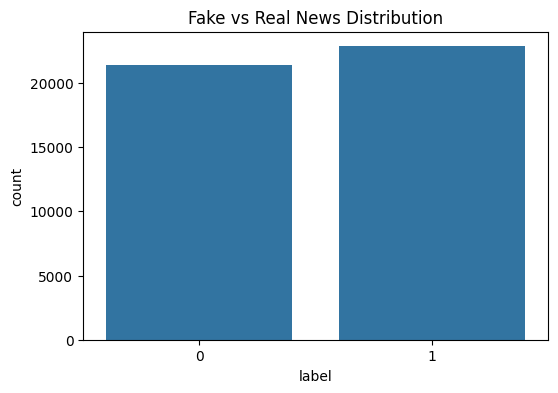

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Fake vs Real News Distribution")

plt.show()

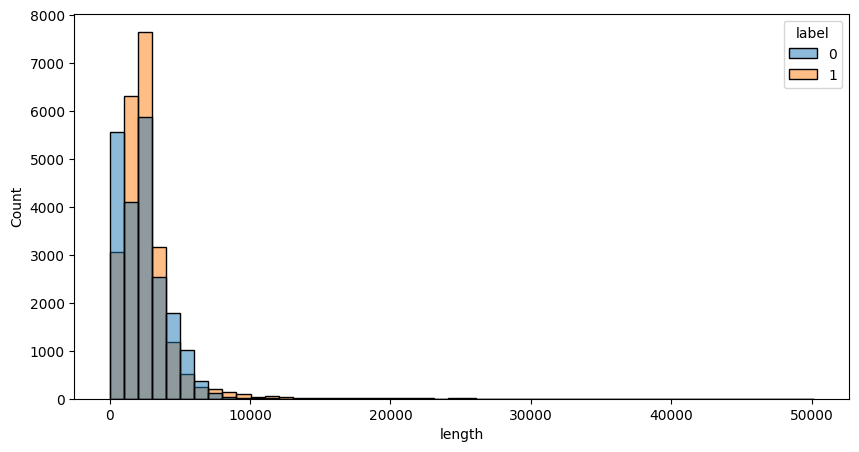

In [45]:
df['length'] = df['content'].apply(len)

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='length',
    hue='label',
    bins=50
)

plt.show()

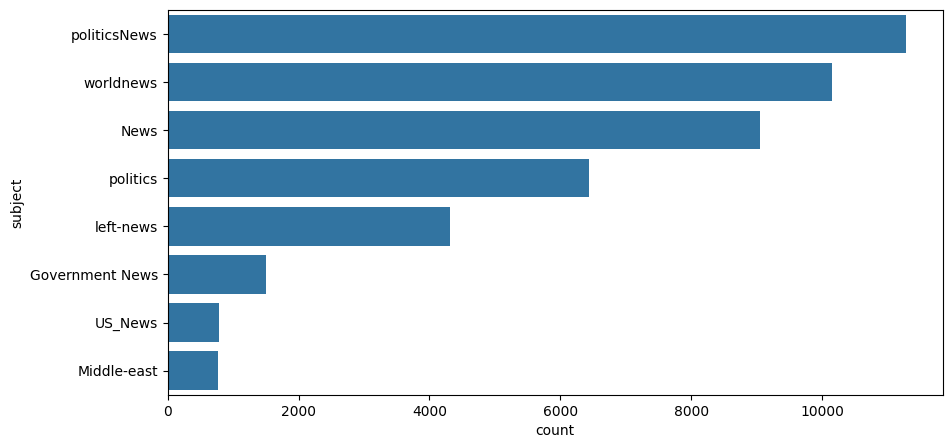

In [46]:
plt.figure(figsize=(10,5))

sns.countplot(
    y=df['subject'],
    order=df['subject'].value_counts().index
)

plt.show()

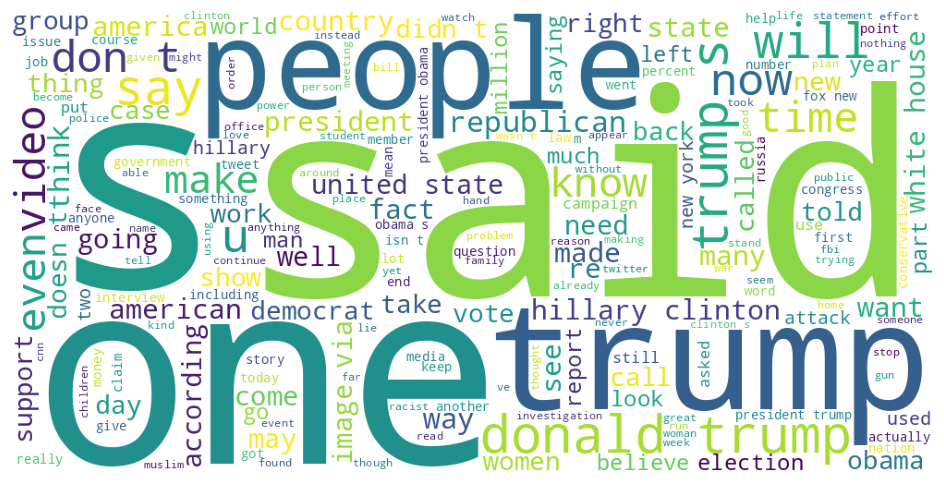

In [47]:
from wordcloud import WordCloud

fake_text = " ".join(
    df[df['label']==1]['content']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

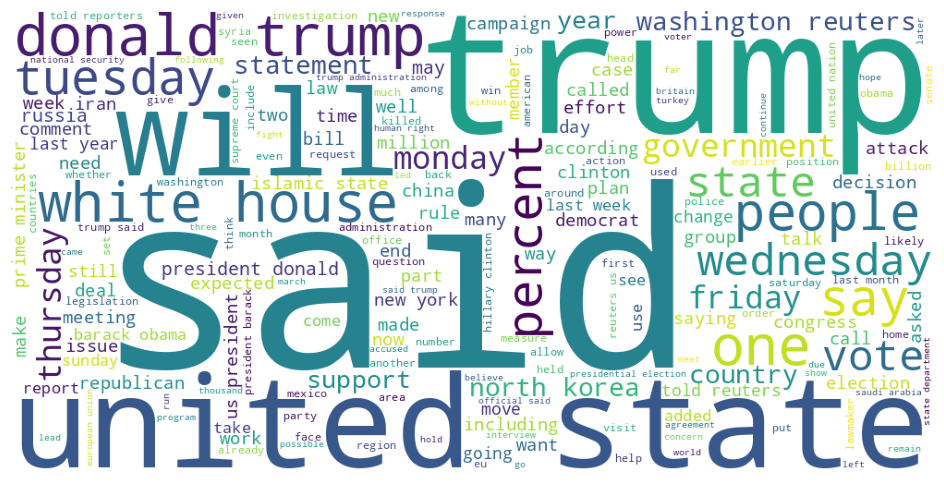

In [49]:
from wordcloud import WordCloud

fake_text = " ".join(
    df[df['label']==0]['content']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

# Train-Test Split

In [50]:
from sklearn.model_selection import train_test_split

X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## TF-IDF

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [52]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(35413, 5000)
(8854, 5000)


# 1. Logistic Regression

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

pred_lr = lr.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, pred_lr))

print(classification_report(y_test, pred_lr))

Accuracy: 0.9902868759882539
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4283
           1       0.99      0.99      0.99      4571

    accuracy                           0.99      8854
   macro avg       0.99      0.99      0.99      8854
weighted avg       0.99      0.99      0.99      8854



# 2. Naive Bayes

In [54]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

pred_nb = nb.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, pred_nb))

print(classification_report(y_test, pred_nb))

Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      4283
           1       0.95      0.95      0.95      4571

    accuracy                           0.95      8854
   macro avg       0.95      0.95      0.95      8854
weighted avg       0.95      0.95      0.95      8854



# 3. Random Forest

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_tfidf, y_train)

pred_rf = rf.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, pred_rf))

print(classification_report(y_test, pred_rf))

Accuracy: 0.9978540772532188
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4283
           1       1.00      1.00      1.00      4571

    accuracy                           1.00      8854
   macro avg       1.00      1.00      1.00      8854
weighted avg       1.00      1.00      1.00      8854



# 4. Accuracy Comparison

In [57]:
lr_acc = accuracy_score(y_test, pred_lr)
nb_acc = accuracy_score(y_test, pred_nb)
rf_acc = accuracy_score(y_test, pred_rf)

In [58]:
import pandas as pd

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy":[
        lr_acc,
        nb_acc,
        rf_acc
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.990287
1          Naive Bayes  0.947368
2        Random Forest  0.997854


# 5. Accuracy Bar Chart

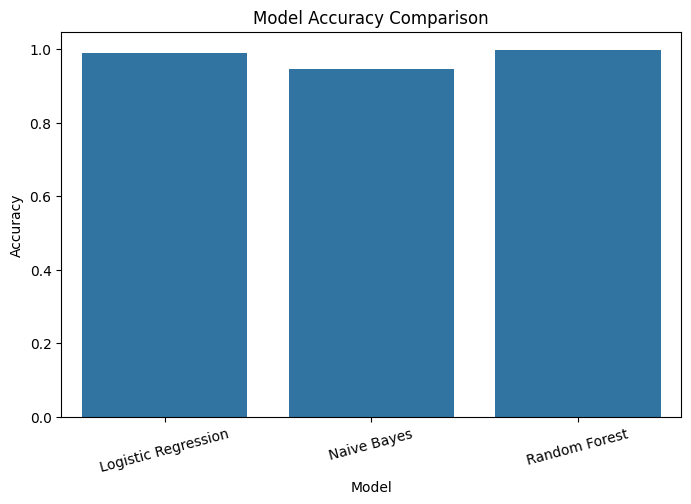

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

# 6. ROC-AUC (Best Model)

In [60]:
from sklearn.metrics import roc_curve, auc

y_prob = lr.predict_proba(X_test_tfidf)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr,tpr)

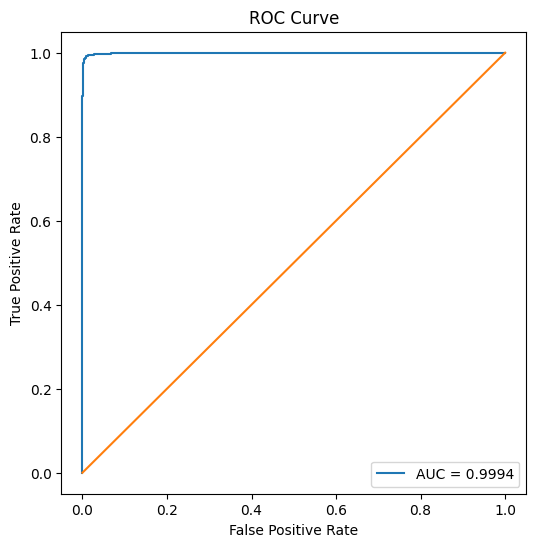

In [61]:
plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# 7. Neural Network

In [62]:
print(results)

                 Model  Accuracy
0  Logistic Regression  0.990287
1          Naive Bayes  0.947368
2        Random Forest  0.997854


# 1. Stopword Removal

In [65]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [66]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# 2. Stemming

In [67]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

def stem_text(text):
    return " ".join([ps.stem(word) for word in text.split()])

# 3. Lemmatization

In [68]:
import nltk
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return " ".join(
        [lemmatizer.lemmatize(word) for word in text.split()]
    )

# 4. Most Frequent Words Analysis

In [69]:
from collections import Counter

all_words = " ".join(df['content']).split()

Counter(all_words).most_common(20)

[('the', 1016656),
 ('to', 551947),
 ('of', 448782),
 ('a', 412572),
 ('and', 410410),
 ('in', 354455),
 ('that', 238186),
 ('on', 196493),
 ('for', 179231),
 ('s', 176524),
 ('is', 169351),
 ('he', 132178),
 ('said', 130259),
 ('trump', 128311),
 ('it', 126656),
 ('with', 121323),
 ('was', 116611),
 ('as', 105277),
 ('his', 97858),
 ('by', 96942)]

# 5. N-Gram Analysis

In [70]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(ngram_range=(2,2))

X_bigram = cv.fit_transform(df['content'])

In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [72]:
X_train_nn = X_train_tfidf.toarray()
X_test_nn = X_test_tfidf.toarray()

In [85]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(5000,)),
    Dropout(0.2),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [93]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [94]:
history = model.fit(
    X_train_nn,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 28s 31ms/step - accuracy: 0.9962 - loss: 0.0120 - val_accuracy: 0.9922 - val_loss: 0.0226
Epoch 2/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.9985 - loss: 0.0036 - val_accuracy: 0.9931 - val_loss: 0.0244
Epoch 3/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9995 - loss: 0.0012 - val_accuracy: 0.9935 - val_loss: 0.0293
Epoch 4/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9998 - loss: 6.8327e-04 - val_accuracy: 0.9934 - val_loss: 0.0337
Epoch 5/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9996 - loss: 0.0012 - val_accuracy: 0.9929 - val_loss: 0.0335
Epoch 6/20
886/886 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9996 - loss: 0.0011 - val_accuracy: 0.9911 - val_loss: 0.0397


In [95]:
for i in range(len(history.history['accuracy'])):
    print(
        f"Epoch {i+1}: "
        f"Train Acc = {history.history['accuracy'][i]:.4f}, "
        f"Val Acc = {history.history['val_accuracy'][i]:.4f}"
    )

Epoch 1: Train Acc = 0.9962, Val Acc = 0.9922
Epoch 2: Train Acc = 0.9985, Val Acc = 0.9931
Epoch 3: Train Acc = 0.9995, Val Acc = 0.9935
Epoch 4: Train Acc = 0.9998, Val Acc = 0.9934
Epoch 5: Train Acc = 0.9996, Val Acc = 0.9929
Epoch 6: Train Acc = 0.9996, Val Acc = 0.9911


In [96]:
print("Final Training Accuracy:",
      history.history['accuracy'][-1])

print("Final Validation Accuracy:",
      history.history['val_accuracy'][-1])

Final Training Accuracy: 0.9995764493942261
Final Validation Accuracy: 0.9911054372787476


In [97]:
test_loss, test_acc = model.evaluate(
    X_test_nn,
    y_test,
    verbose=0
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

Test Accuracy: 0.9922069311141968
Test Loss: 0.02711038663983345


# 1. Training Accuracy

In [99]:
train_loss, train_acc = model.evaluate(
    X_train_nn,
    y_train,
    verbose=0
)

print("Training Accuracy:", train_acc)

Training Accuracy: 0.9976844787597656


# 2. Testing Accuracy

In [100]:
test_loss, test_acc = model.evaluate(
    X_test_nn,
    y_test,
    verbose=0
)

print("Testing Accuracy:", test_acc)

Testing Accuracy: 0.9922069311141968


In [101]:
train_loss, train_acc = model.evaluate(X_train_nn, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test_nn, y_test, verbose=0)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")

print(f"Training Loss: {train_loss:.4f}")
print(f"Testing Loss: {test_loss:.4f}")

Training Accuracy: 0.9977
Testing Accuracy: 0.9922
Training Loss: 0.0068
Testing Loss: 0.0271
